In [1]:
%pip install ipykernel matplotlib numpy pandas scikit-learn seaborn requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import pickle
from pprint import pprint
from pathlib import Path
from zipfile import ZipFile

import numpy
import pandas
import seaborn
import requests
from pandas import DataFrame
from matplotlib import pyplot
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

from helper import parse_url, analyze_url

# Analyzing dataset

In [3]:
# Pandas configuration.
pandas.set_option("display.max_columns", None)
pandas.set_option('display.max_colwidth', None)

In [4]:
# Download dataset ZIP and extract dataset file (dataset.csv have ~50MB which Github doesn't like, so it is zipped).
if not Path("dataset.csv").exists():
    if not Path("dataset.zip").exists():
        response = requests.get("https://github.com/thiagola92/pucpos-qualidade/raw/refs/heads/main/backend/machine_learning/dataset.zip")
        assert response.status_code == 200, "Failed to get CSV from Github"
        Path("dataset.zip").write_bytes(response.content)
    
    ZipFile("dataset.zip").extract("dataset.csv")

# Load dataset.
dataset = pandas.read_csv("dataset.csv")
dataset = dataset[["URL", "label"]]
dataset = dataset.rename(columns={"URL": "url"})
dataset.head()

,url,label
0,https://www.southbankmosaics.com,1
1,https://www.uni-mainz.de,1
2,https://www.voicefmradio.co.uk,1
3,https://www.sfnmjournal.com,1
4,https://www.rewildingargentina.org,1


In [5]:
dataset[["label"]].value_counts()

label
1        134850
0        100945
Name: count, dtype: int64

In [6]:
# Download phishing dataset (dataset_phishing.csv has 10MB so it is fine to download through pandas).
file = "dataset_phishing.csv"

if not Path(file).exists():
    file = "https://github.com/thiagola92/pucpos-qualidade/raw/refs/heads/main/backend/machine_learning/dataset_phishing.csv"

# Load dataset phishing.
dataset_phishing = pandas.read_csv(file)
dataset_phishing = dataset_phishing[["url"]]
dataset_phishing = dataset_phishing.assign(label=0)
dataset_phishing.head()

,url,label
0,https://global-ledgr.ghost.io/,0
1,https://global-software.ghost.io/,0
2,https://trzkmds900d.vincent-a05.workers.dev/,0
3,https://enbridge.zapier.app/bridge-en,0
4,https://https0709-csky1y-dot-my-project-80459kci.ew.r.appspot.com/#YWRyaWFuLnBsYXphQHZsaWVzbW8uY29t,0


In [7]:
dataset_phishing[["label"]].value_counts()

label
0        55982
Name: count, dtype: int64

In [8]:
dataset_new = pandas.concat([dataset, dataset_phishing])
dataset_new.head()

,url,label
0,https://www.southbankmosaics.com,1
1,https://www.uni-mainz.de,1
2,https://www.voicefmradio.co.uk,1
3,https://www.sfnmjournal.com,1
4,https://www.rewildingargentina.org,1


In [9]:
dataset_new[["label"]].value_counts()

label
0        156927
1        134850
Name: count, dtype: int64

In [10]:
# Create a new dataset, using logic that we can reproduce.
data_parsed = {
    "url": [],
    # URL parsed
    "scheme": [],
    "netloc": [],
    "path": [],
    "query": [],
    "fragment": [],
    # Path parsed
    "paths": [],
    # Netloc parsed
    "username": [],
    "password": [],
    "hostname": [],
    "port": [],
    # Domain parsed
    "domains": [],
    "tld": [],
    "sld": [],
    "subdomain": [],
    "label": [],
}

for value in dataset_new[["url", "label"]].values:
    url = value[0]
    result = parse_url(url)

    for k, v in result.items():
        data_parsed[k].append(v)
    
    data_parsed["label"].append(value[1])

dataset_parsed = DataFrame(data=data_parsed, columns=list(data_parsed.keys()))

dataset_parsed.head()

,url,scheme,netloc,path,query,fragment,paths,username,password,hostname,port,domains,tld,sld,subdomain,label
0,https://www.southbankmosaics.com,https,www.southbankmosaics.com,/,,,[],,,www.southbankmosaics.com,None,"[southbankmosaics, com]",com,southbankmosaics,,1
1,https://www.uni-mainz.de,https,www.uni-mainz.de,/,,,[],,,www.uni-mainz.de,None,"[uni-mainz, de]",de,uni-mainz,,1
2,https://www.voicefmradio.co.uk,https,www.voicefmradio.co.uk,/,,,[],,,www.voicefmradio.co.uk,None,"[voicefmradio, co, uk]",uk,co,voicefmradio,1
3,https://www.sfnmjournal.com,https,www.sfnmjournal.com,/,,,[],,,www.sfnmjournal.com,None,"[sfnmjournal, com]",com,sfnmjournal,,1
4,https://www.rewildingargentina.org,https,www.rewildingargentina.org,/,,,[],,,www.rewildingargentina.org,None,"[rewildingargentina, org]",org,rewildingargentina,,1


In [11]:
# Getting used TLDs in legit URLs and it occurrences.
dataset_trusted_tlds = dataset_parsed.query("label == 1")[["tld"]]
tld_occurrence = {}

for i in dataset_trusted_tlds.value_counts().items():
    tld_occurrence[i[0][0]] = i[1]

# For visualization.
dataset_trusted_tlds.value_counts()

tld     
com         68785
org         16524
uk           6073
net          3998
de           3310
            ...  
ntt             1
madrid          1
services        1
film            1
ne              1
Name: count, Length: 473, dtype: int64

In [12]:
data_analyzed = {
    # Flags
    "is_https":[],
    "is_http":[],
    "is_auth":[],
    "is_ip":[],
    "has_port":[],
    # Length
    "scheme_length":[],
    "path_length":[],
    "query_length":[],
    "fragment_length":[],
    "username_length":[],
    "password_length":[],
    "port_length":[],
    "tld_length":[],
    "sld_length":[],
    "subdomain_length":[],
    # Count
    "domains_count":[],
    "paths_count":[],
    # Ratio
    "path_d_ratio": [],
    "path_l_ratio": [],
    "path_o_ratio": [],
    "tld_d_ratio": [],
    "tld_l_ratio": [],
    "tld_o_ratio": [],
    "sld_d_ratio": [],
    "sld_l_ratio": [],
    "sld_o_ratio": [],
    "subdomain_d_ratio": [],
    "subdomain_l_ratio": [],
    "subdomain_o_ratio": [],
    # Occurrence
    "tld_occurrence": [],
    # Label
    "label": [],
}

for value in dataset_parsed[["url", "label"]].values:
    url = value[0]
    label = value[-1]
    result = analyze_url(url, tld_occurrence)

    for k, v in result.items():
        data_analyzed[k].append(v)
    
    data_analyzed["label"].append(label)

dataset_analyzed = DataFrame(data=data_analyzed, columns=list(data_analyzed.keys()))

dataset_analyzed.head()

,is_https,is_http,is_auth,is_ip,has_port,scheme_length,path_length,query_length,fragment_length,username_length,password_length,port_length,tld_length,sld_length,subdomain_length,domains_count,paths_count,path_d_ratio,path_l_ratio,path_o_ratio,tld_d_ratio,tld_l_ratio,tld_o_ratio,sld_d_ratio,sld_l_ratio,sld_o_ratio,subdomain_d_ratio,subdomain_l_ratio,subdomain_o_ratio,tld_occurrence,label
0,1,0,0,0,1,5,1,0,0,0,0,4,3,16,0,2,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.000000,0.0,0.0,1.0,68785,1
1,1,0,0,0,1,5,1,0,0,0,0,4,2,9,0,2,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.888889,0.111111,0.0,0.0,1.0,3310,1
2,1,0,0,0,1,5,1,0,0,0,0,4,2,2,12,3,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.000000,0.0,1.0,0.0,6073,1
3,1,0,0,0,1,5,1,0,0,0,0,4,3,11,0,2,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.000000,0.0,0.0,1.0,68785,1
4,1,0,0,0,1,5,1,0,0,0,0,4,3,18,0,2,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.000000,0.0,0.0,1.0,16524,1


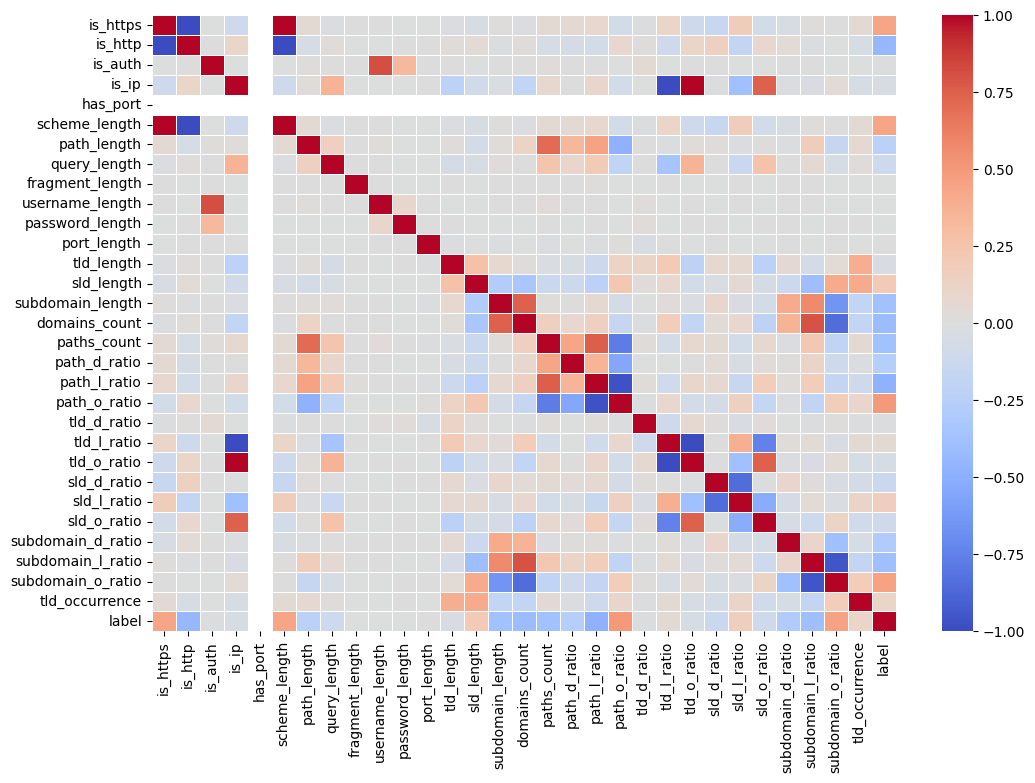

In [13]:
# Plot heatmap.
pyplot.figure(figsize=(12,8))
seaborn.heatmap(dataset_analyzed.corr('pearson'), annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
pyplot.show()

# Creating model

In [14]:
# Split between features and classification.
X = dataset_analyzed.drop(columns=["label"])
y = dataset_analyzed["label"]

seed = 7
kfold = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=seed
)

# Split dataset between training and tests.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    shuffle=True,
    random_state=seed,
    stratify=y
)

# Classifiers.
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
random_forest = ('RF', RandomForestClassifier())
svm = ('SVM', SVC())

# Transformers.
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Pipelines.
pipelines = [
    # Dataset original.
    ('orig-KNN', Pipeline([knn])),
    ('orig-CART', Pipeline([cart])),
    ('orig-NB', Pipeline([naive_bayes])),
    ('orig-RF', Pipeline([random_forest])),
    # ('SVM-orig', Pipeline([svm])), # Taking too long.
    
    # Dataset standarized.
    ('stand-KNN', Pipeline([standard_scaler, knn])),
    ('stand-CART', Pipeline([standard_scaler, cart])),
    ('stand-NB', Pipeline([standard_scaler, naive_bayes])),
    ('stand-RF', Pipeline([standard_scaler, random_forest])),
    # ('SVM-padr', Pipeline([standard_scaler, svm])), # Taking too long.

    # Dataset normalized.
    ('norm-KNN', Pipeline([min_max_scaler, knn])),
    ('norm-CART', Pipeline([min_max_scaler, cart])),
    ('norm-NB', Pipeline([min_max_scaler, naive_bayes])),
    ('norm-RF', Pipeline([min_max_scaler, random_forest])),
    # ('SVM-norm', Pipeline([min_max_scaler, svm])), # Taking too long.
]

In [15]:
results = []

# Check the result when training with X_train and y_train.
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    
    results.append((name, model, cv_results))
    
    print("score of %s: %.5f (deviation of %.5f)" % (name, cv_results.mean(), cv_results.std()))

score of orig-KNN: 0.98142 (deviation of 0.00078)
score of orig-CART: 0.98494 (deviation of 0.00065)
score of orig-NB: 0.73668 (deviation of 0.00389)
score of orig-RF: 0.98617 (deviation of 0.00062)
score of stand-KNN: 0.98334 (deviation of 0.00050)
score of stand-CART: 0.98486 (deviation of 0.00078)
score of stand-NB: 0.87624 (deviation of 0.00326)
score of stand-RF: 0.98604 (deviation of 0.00058)
score of norm-KNN: 0.98344 (deviation of 0.00074)
score of norm-CART: 0.98486 (deviation of 0.00074)
score of norm-NB: 0.88573 (deviation of 0.00292)
score of norm-RF: 0.98610 (deviation of 0.00069)


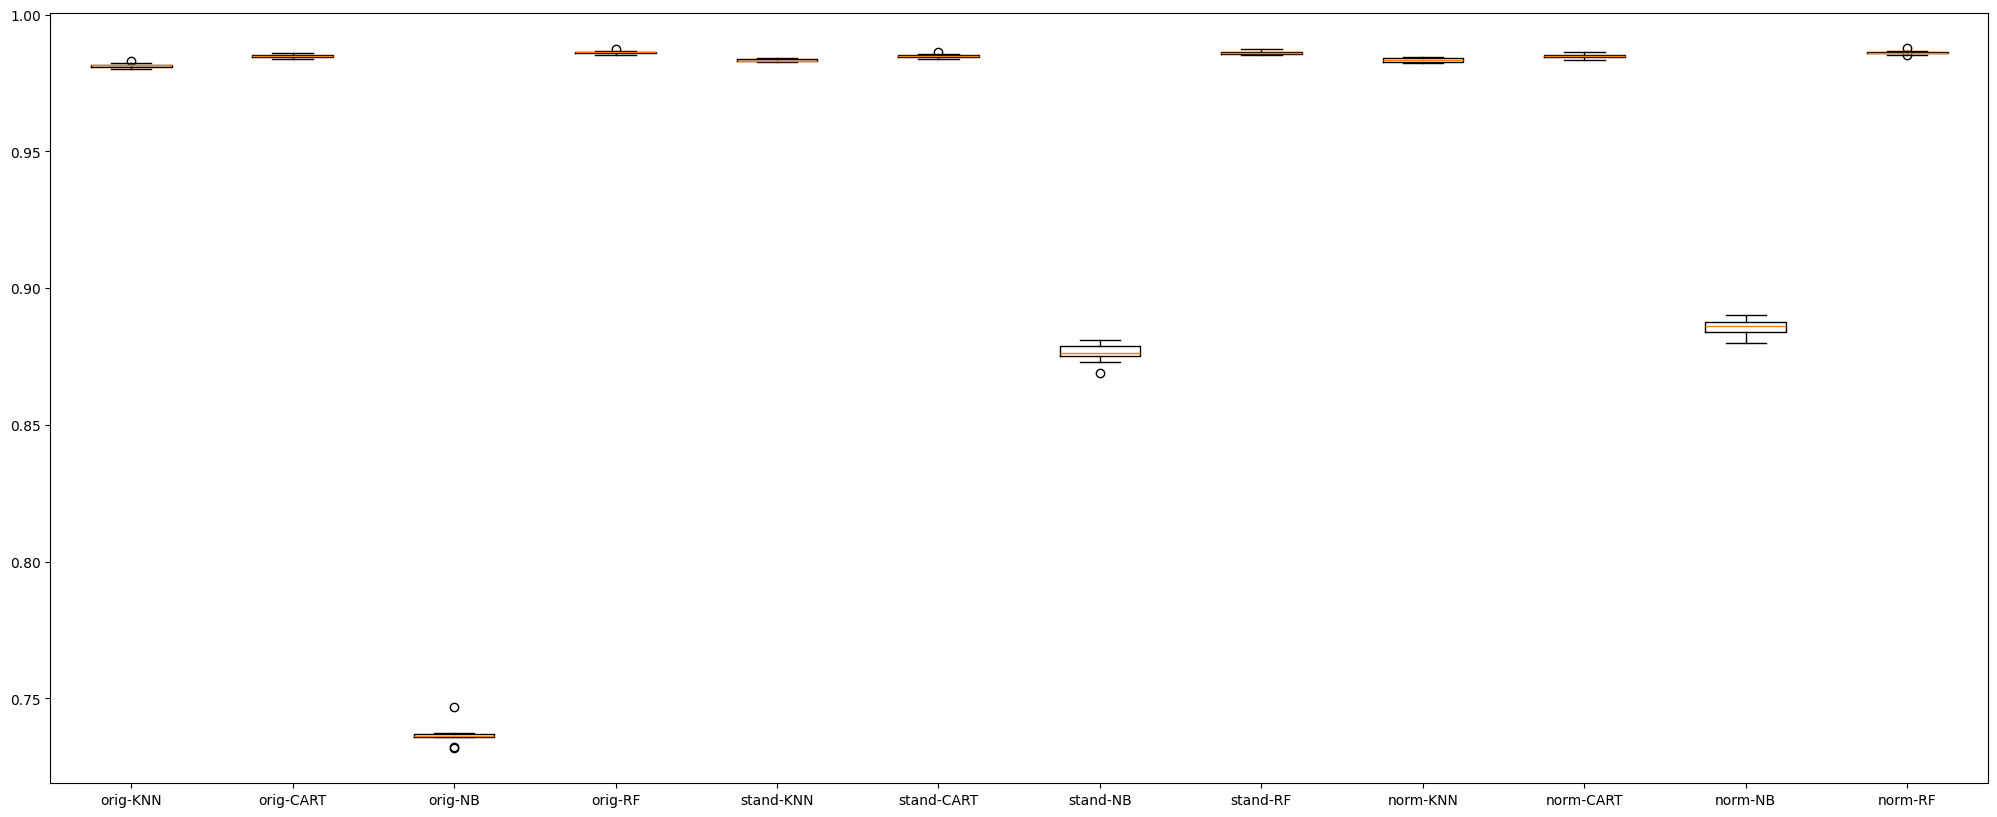

In [16]:
# Plot results boxplots.
figure = pyplot.figure(figsize=(25,10))
axes = figure.add_subplot(111)

pyplot.boxplot([r[2] for r in results])
axes.set_xticklabels([r[0] for r in results])
pyplot.show()

In [17]:
# Get the best score.
best_name = None
best_model = None
best_score = 0

for name, model, cv_results in results:
    if cv_results.mean() > best_score:
        best_score = cv_results.mean()
        best_name = name
        best_model = model

print(f"Best model: {best_name}")

Best model: orig-RF


In [18]:
# Pipelines of Random Forest.
rf_pipelines = [
    ('orig-RF', Pipeline([random_forest])),
    ('stand-RF', Pipeline([standard_scaler, random_forest])),
    ('norm-RF', Pipeline([min_max_scaler, random_forest])),
]

# Setting hyperparameters to test.
param_grid = {
    "RF__n_estimators": [10, 100, 200],
    "RF__criterion": ["gini", "entropy", "log_loss"],
    # Taking too long.
    # "RF__max_depth": [10, 20, 30],
    # "RF__min_samples_split": [2, 3],
    # "RF__min_samples_leaf": [1, 2],
    # "RF__max_features": ["sqrt", None],
}

In [19]:
# Finding best hyperparameters for Random Forest.
rf_results = []

numpy.random.seed(seed)

for name, model in rf_pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy')
    
    grid.fit(X_train, y_train)
    rf_results.append((name, grid.best_estimator_, grid.best_score_, grid.best_params_))
    
    print("%s melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

orig-RF melhor: 0.985902 usando {'RF__criterion': 'entropy', 'RF__n_estimators': 200}
stand-RF melhor: 0.985908 usando {'RF__criterion': 'log_loss', 'RF__n_estimators': 200}
norm-RF melhor: 0.985908 usando {'RF__criterion': 'gini', 'RF__n_estimators': 100}


In [20]:
# Get the Random Forest.
best_rf = None
best_rf_model = None
best_rf_score = 0
best_rf_params = None

for name, model, score, params in rf_results:
    if score > best_rf_score:
        best_rf = name
        best_rf_model = model
        best_rf_score = score
        best_rf_params = params

print(f"Best RF model: {best_rf} with {best_rf_params}")

Best RF model: stand-RF with {'RF__criterion': 'log_loss', 'RF__n_estimators': 200}


In [21]:
# Test predictions.
best_rf_model.fit(X_train, y_train)
predictions = best_rf_model.predict(X_test)

accuracy_score(y_test, predictions)

0.9869335366846312

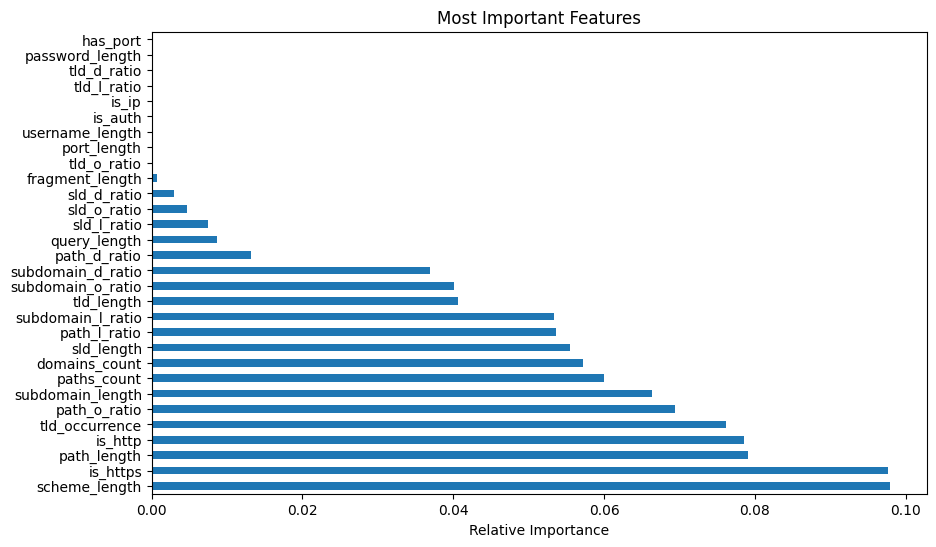

In [22]:
# Plotting most important features
pyplot.figure(figsize=(10, 6))
feat_importances = pandas.Series(best_rf_model[1].feature_importances_, index=X.columns)
feat_importances.nlargest(len(X.columns)).plot(kind='barh')
pyplot.title('Most Important Features')
pyplot.xlabel('Relative Importance')
pyplot.show()

In [23]:
# Paths to save.
model_path = Path("./model.pkl")
tld_path = Path("./tld.json")

# Train using full dataset and save model.
best_rf_model.fit(X, y)

with open(model_path, "wb") as f:
    pickle.dump(best_rf_model, f)

# Save TLD json.
with open(tld_path, "wb") as f:
    tld_path.write_text(json.dumps(tld_occurrence))

# Simulating using model

In [24]:
# Load model from file.
model = pickle.loads(model_path.read_bytes())
tlds = json.loads(tld_path.read_text())

# Create a simple testing function.
def test_url(url):
    data = analyze_url(url, tlds)

    for k in data:
        data[k] = [data[k]]

    dataframe = DataFrame(data=data, columns=list(data.keys()))
    result = model.predict(dataframe)[0]

    if result == 1:
        print("LEGIT", url)
    else:
        print("PHISHING", url)

In [25]:
print("-------------------- Expected to be legit --------------------")
test_url("https://www.google.com")
test_url("https://www.facebook.com")
test_url("https://www.southbankmosaics.com")
test_url("https://www.voicefmradio.co.uk")
test_url("https://www.github.com")
test_url("https://www.github.com/")
test_url("https://github.com/")
test_url("https://github.com.br/")

print("-------------------- Expected to be phishing --------------------")
test_url("http://www.kuradox92.lima-city.de")
test_url("http://www.f0519141.xsph.ru")
test_url("https://bancolombia.com1home0892.repl.co/?2")
test_url("http://asdf.asdf.bancolombia.com1home0892.repl.co/?2%32%32%32%3zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz2%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32")

-------------------- Expected to be legit --------------------
LEGIT https://www.google.com
LEGIT https://www.facebook.com
LEGIT https://www.southbankmosaics.com
LEGIT https://www.voicefmradio.co.uk
LEGIT https://www.github.com
LEGIT https://www.github.com/
LEGIT https://github.com/
LEGIT https://github.com.br/
-------------------- Expected to be phishing --------------------
PHISHING http://www.kuradox92.lima-city.de
PHISHING http://www.f0519141.xsph.ru
PHISHING https://bancolombia.com1home0892.repl.co/?2
PHISHING http://asdf.asdf.bancolombia.com1home0892.repl.co/?2%32%32%32%3zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz2%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32%32
